# Task-1

In [1]:
from collections import Counter

doc_count = 0
global_tokens = []

# Open and read directly from the saved file
with open("corpus.txt", "r", encoding="utf-8") as file_obj:
    for text_line in file_obj:
        # Split the line by spaces to get individual word tokens
        word_list = text_line.split()
        
        # Only process lines that actually have words
        if len(word_list) > 0:
            doc_count += 1
            global_tokens.extend(word_list)

num_total_tokens = len(global_tokens)
unique_vocab = set(global_tokens)
size_of_vocab = len(unique_vocab)

print("Total Documents:", doc_count)
print("Total Tokens:", num_total_tokens)
print("Vocabulary Size:", size_of_vocab)

Total Documents: 675
Total Tokens: 296425
Vocabulary Size: 16216


In [2]:
frequency_map = Counter(global_tokens)

print("\nTop 10 Words:")
for term, count in frequency_map.most_common(10):
    print(term, count)


Top 10 Words:
lecture 3405
engineering 2948
jodhpur 2794
system 2753
student 2726
department 2575
course 2165
institute 1930
iit 1879
iitj 1793


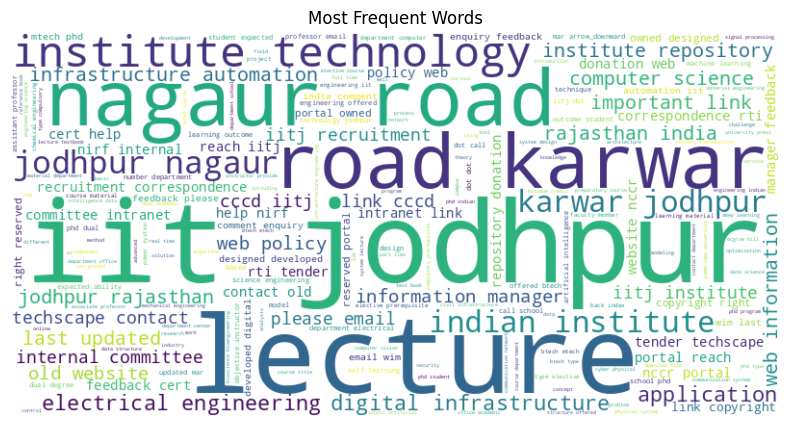

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

joined_text = " ".join(global_tokens)

# Setting parameters for word cloud
wc_img = WordCloud(
    width=800, 
    height=400,
    background_color='white',
    max_words=200
).generate(joined_text)

# Set up the matplotlib figure size (Width: 10 inches, Height: 5 inches)
plt.figure(figsize=(10,5))

# Display the generated word cloud image. 
plt.imshow(wc_img, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words")
plt.show()

# task-2

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import Counter
import numpy as np
import io

# Setup device for GPU acceleration if available
compute_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {compute_device}")

Using device: cuda


In [5]:
# Load the cleaned corpus from Task 1
text_data_path = "corpus.txt"
with io.open(text_data_path, "r", encoding="utf-8") as file_obj:
    parsed_corpus = [line.split() for line in file_obj]

# Count word frequencies across the entire corpus
all_words_flat = [term for document in parsed_corpus for term in document]
token_counts = Counter(all_words_flat)

# Create vocabulary mappings (word to ID, ID to word)
vocab_list = list(token_counts.keys())
w2i_map = {word: idx for idx, word in enumerate(vocab_list)}
i2w_map = {idx: word for word, idx in w2i_map.items()}
vocab_length = len(vocab_list)

# Calculate unigram distribution for negative sampling (freq ^ 0.75)
freq_array = np.array([token_counts[w] for w in vocab_list])
noise_distribution = freq_array ** 0.75
noise_distribution = noise_distribution / noise_distribution.sum()

print(f"Vocabulary Size: {vocab_length}")

Vocabulary Size: 16216


In [6]:
def build_training_pairs(text_corpus, word_dict, win_size, arch_type="skipgram"):
    """Generates (input, target) pairs based on the context window."""
    dataset_pairs = []
    for document in text_corpus:
        doc_indices = [word_dict[w] for w in document]
        for pos, target_idx in enumerate(doc_indices):
            # Determine context window boundaries
            start_idx = max(0, pos - win_size)
            end_idx = min(len(doc_indices), pos + win_size + 1)
            
            # Extract context words (excluding the center word itself)
            ctx_indices = [doc_indices[j] for j in range(start_idx, end_idx) if j != pos]
            if len(ctx_indices) == 0:
                continue
                
            if arch_type == "skipgram":
                # Skip-gram: predict context word from center word
                for ctx_word in ctx_indices:
                    dataset_pairs.append((target_idx, ctx_word))
            elif arch_type == "cbow":
                # CBOW: predict center word from a list of context words
                dataset_pairs.append((ctx_indices, target_idx))
    return dataset_pairs

In [7]:
class SGNegativeSampling(nn.Module):
    """Skip-gram model with Negative Sampling."""
    def __init__(self, size_vocab, dim_embed):
        super(SGNegativeSampling, self).__init__()
        self.emb_input = nn.Embedding(size_vocab, dim_embed)  # Center word embeddings
        self.emb_output = nn.Embedding(size_vocab, dim_embed) # Context word embeddings
        
    def forward(self, target_w, context_w, neg_w):
        vec_tgt = self.emb_input(target_w)
        vec_ctx = self.emb_output(context_w)
        vec_neg = self.emb_output(neg_w)
        
        # Maximize similarity between center and actual context
        positive_scores = torch.sum(vec_tgt * vec_ctx, dim=1)
        loss_pos = -torch.nn.functional.logsigmoid(positive_scores)
        
        # Minimize similarity between center and negative samples
        negative_scores = torch.bmm(vec_neg, vec_tgt.unsqueeze(2)).squeeze(2)
        loss_neg = -torch.sum(torch.nn.functional.logsigmoid(-negative_scores), dim=1)
        
        return torch.mean(loss_pos + loss_neg)


class CBOWNegativeSampling(nn.Module):
    """CBOW model with Negative Sampling."""
    def __init__(self, size_vocab, dim_embed):
        super(CBOWNegativeSampling, self).__init__()
        self.emb_input = nn.Embedding(size_vocab, dim_embed)  # Context word embeddings
        self.emb_output = nn.Embedding(size_vocab, dim_embed) # Center word embeddings
        
    def forward(self, context_w, target_w, neg_w):
        # Average the embeddings of the context words
        vec_ctx = self.emb_input(context_w).mean(dim=1)
        
        vec_tgt = self.emb_output(target_w)
        vec_neg = self.emb_output(neg_w)
        
        # Maximize similarity between average context and actual center word
        positive_scores = torch.sum(vec_ctx * vec_tgt, dim=1)
        loss_pos = -torch.nn.functional.logsigmoid(positive_scores)
        
        # Minimize similarity between average context and negative samples
        negative_scores = torch.bmm(vec_neg, vec_ctx.unsqueeze(2)).squeeze(2)
        loss_neg = -torch.sum(torch.nn.functional.logsigmoid(-negative_scores), dim=1)
        
        return torch.mean(loss_pos + loss_neg)

In [ ]:
def execute_training(net_model, train_data, noise_dist, comp_device, num_epochs, b_size, n_negatives):
    """
    Trains the Word2Vec model (either Skip-gram or CBOW) using Negative Sampling.
    Returns the final average loss after all epochs are completed.
    """

    net_model = net_model.to(comp_device)
    opt = optim.Adam(net_model.parameters(), lr=0.001)
    
    net_model.train()
    

    def sample_noise_words(current_b_size, count_neg):
        """
        Draws 'noise' words from the vocabulary based on their modified unigram frequency.
        More frequent words are picked more often as negative examples.
        """
        noise_samples = np.random.choice(len(noise_dist), size=(current_b_size, count_neg), p=noise_dist)
        return torch.tensor(noise_samples, dtype=torch.long)

    avg_epoch_loss = 0
    

    for current_epoch in range(num_epochs):
        accumulated_loss = 0
        
        # Shuffle the data at the start of each epoch for better stochastic gradient descent
        random.shuffle(train_data) 
        
        # Process the training data in chunks (batches) to optimize memory and speed
        for idx in range(0, len(train_data), b_size):
            batch_chunk = train_data[idx:idx+b_size]
            actual_size = len(batch_chunk)
            

            # If the input is a list, this is CBOW (predicting center from multiple context words).
            if isinstance(batch_chunk[0][0], list):
                inp_tensors = []
                # Find the maximum context window size in this specific batch
                max_pad_len = max(len(element[0]) for element in batch_chunk)
                
                # Context windows at the very beginning/end of a document might be smaller.
                # so padding them by repeating their first element so they form a perfect rectangular tensor.
                for element in batch_chunk:
                    padded_context = element[0] + [element[0][0]] * (max_pad_len - len(element[0]))
                    inp_tensors.append(padded_context)
                inp_tensors = torch.tensor(inp_tensors, dtype=torch.long)
                
            # Otherwise this is Skip-gram (predicting context from a single center word).
            else:
                inp_tensors = torch.tensor([element[0] for element in batch_chunk], dtype=torch.long)

            # Extract the correct target words for the batch
            tgt_tensors = torch.tensor([element[1] for element in batch_chunk], dtype=torch.long)
            
            # Generate the 'fake' negative words for the model to contrast against the real targets
            neg_tensors = sample_noise_words(actual_size, n_negatives)
            
            # Move all tensors to the active device (GPU/CPU)
            inp_tensors = inp_tensors.to(comp_device)
            tgt_tensors = tgt_tensors.to(comp_device)
            neg_tensors = neg_tensors.to(comp_device)
            

            opt.zero_grad()
            
            # Forward pass: Compute the loss using the models custom forward() method
            computed_loss = net_model(inp_tensors, tgt_tensors, neg_tensors)
            
            # Backward pass: Calculate how much each weight contributed to the error
            computed_loss.backward()
            
            # Update weights based on the gradients
            opt.step()
            
            # Tracking the running total of the loss for this epoch
            accumulated_loss += computed_loss.item()
        
        # Calculate and print the average loss across all batches in this epoch
        avg_epoch_loss = accumulated_loss / len(train_data)
        print(f"      Epoch {current_epoch+1} | Loss: {avg_epoch_loss:.4f}")
        
    return avg_epoch_loss

In [ ]:
# Defining the experiment parameters specified in Task 2
embedding_sizes = [50, 100, 200, 300]
ctx_windows = [2, 4]
neg_sample_counts = [3, 5]

total_epochs = 5
batch_cap = 128
experiment_logs = []

# Dictionary to store all trained models 
trained_models = {}

print("Starting Grid Search...")
for e_dim in embedding_sizes:
    for w_size in ctx_windows:
        print(f"\n--- Generating Data for Window Size: {w_size} ---")
        sg_dataset = build_training_pairs(parsed_corpus, w2i_map, w_size, "skipgram")
        cbow_dataset = build_training_pairs(parsed_corpus, w2i_map, w_size, "cbow")
        
        for n_samples in neg_sample_counts:
            print(f"\n>>> Running: Dim={e_dim}, Win={w_size}, Neg={n_samples} <<<")
            
            # Initialize and train Skip-gram
            print("   [Skip-gram]")
            sg_net = SGNegativeSampling(vocab_length, e_dim)
            loss_sg = execute_training(sg_net, sg_dataset, noise_distribution, compute_device, total_epochs, batch_cap, n_samples)
            
            # Save the trained Skip-gram model into the dictionary ---
            sg_key = f"Skip-gram_Dim{e_dim}_Win{w_size}_Neg{n_samples}"
            trained_models[sg_key] = sg_net
            
            # Initialize and train CBOW
            print("   [CBOW]")
            cbow_net = CBOWNegativeSampling(vocab_length, e_dim)
            loss_cbow = execute_training(cbow_net, cbow_dataset, noise_distribution, compute_device, total_epochs, batch_cap, n_samples)
            
            # Save the trained CBOW model into the dictionary ---
            cbow_key = f"CBOW_Dim{e_dim}_Win{w_size}_Neg{n_samples}"
            trained_models[cbow_key] = cbow_net
            
            # Save results to format later for the report
            experiment_logs.append({
                "Model": "Skip-gram", 
                "Dim": e_dim, 
                "Win": w_size, 
                "Neg": n_samples, 
                "Loss": loss_sg
            })
            experiment_logs.append({
                "Model": "CBOW", 
                "Dim": e_dim, 
                "Win": w_size, 
                "Neg": n_samples, 
                "Loss": loss_cbow
            })
            
print("\nTraining Complete!")

Starting Grid Search...

--- Generating Data for Window Size: 2 ---

>>> Running: Dim=50, Win=2, Neg=3 <<<
   [Skip-gram]
      Epoch 1 | Loss: 0.0596
      Epoch 2 | Loss: 0.0311
      Epoch 3 | Loss: 0.0207
      Epoch 4 | Loss: 0.0163
      Epoch 5 | Loss: 0.0139
   [CBOW]
      Epoch 1 | Loss: 0.0431
      Epoch 2 | Loss: 0.0346
      Epoch 3 | Loss: 0.0276
      Epoch 4 | Loss: 0.0216
      Epoch 5 | Loss: 0.0173

>>> Running: Dim=50, Win=2, Neg=5 <<<
   [Skip-gram]
      Epoch 1 | Loss: 0.0836
      Epoch 2 | Loss: 0.0357
      Epoch 3 | Loss: 0.0229
      Epoch 4 | Loss: 0.0184
      Epoch 5 | Loss: 0.0159
   [CBOW]
      Epoch 1 | Loss: 0.0647
      Epoch 2 | Loss: 0.0472
      Epoch 3 | Loss: 0.0323
      Epoch 4 | Loss: 0.0237
      Epoch 5 | Loss: 0.0188

--- Generating Data for Window Size: 4 ---

>>> Running: Dim=50, Win=4, Neg=3 <<<
   [Skip-gram]
      Epoch 1 | Loss: 0.0461
      Epoch 2 | Loss: 0.0198
      Epoch 3 | Loss: 0.0148
      Epoch 4 | Loss: 0.0128
      Epoc

In [10]:
# Print the final parameter list as a Markdown Table
print("\n--- Markdown Table for Report ---")
print("| Model | Embedding Size (Dim) | Context Window (Win) | Negative Samples (Neg) | Final Loss |")
print("|---|---|---|---|---|")
for log in experiment_logs:
    print(f"| {log['Model']} | {log['Dim']} | {log['Win']} | {log['Neg']} | {log['Loss']:.4f} |")


--- Markdown Table for Report ---
| Model | Embedding Size (Dim) | Context Window (Win) | Negative Samples (Neg) | Final Loss |
|---|---|---|---|---|
| Skip-gram | 50 | 2 | 3 | 0.0139 |
| CBOW | 50 | 2 | 3 | 0.0173 |
| Skip-gram | 50 | 2 | 5 | 0.0159 |
| CBOW | 50 | 2 | 5 | 0.0188 |
| Skip-gram | 50 | 4 | 3 | 0.0116 |
| CBOW | 50 | 4 | 3 | 0.0141 |
| Skip-gram | 50 | 4 | 5 | 0.0137 |
| CBOW | 50 | 4 | 5 | 0.0158 |
| Skip-gram | 100 | 2 | 3 | 0.0154 |
| CBOW | 100 | 2 | 3 | 0.0185 |
| Skip-gram | 100 | 2 | 5 | 0.0172 |
| CBOW | 100 | 2 | 5 | 0.0202 |
| Skip-gram | 100 | 4 | 3 | 0.0118 |
| CBOW | 100 | 4 | 3 | 0.0138 |
| Skip-gram | 100 | 4 | 5 | 0.0137 |
| CBOW | 100 | 4 | 5 | 0.0155 |
| Skip-gram | 200 | 2 | 3 | 0.0190 |
| CBOW | 200 | 2 | 3 | 0.0213 |
| Skip-gram | 200 | 2 | 5 | 0.0203 |
| CBOW | 200 | 2 | 5 | 0.0230 |
| Skip-gram | 200 | 4 | 3 | 0.0127 |
| CBOW | 200 | 4 | 3 | 0.0138 |
| Skip-gram | 200 | 4 | 5 | 0.0143 |
| CBOW | 200 | 4 | 5 | 0.0156 |
| Skip-gram | 300 | 2 | 3 | 0

# Task-3

In [ ]:
import torch.nn.functional as F

def fetch_embedding_vector(net_model, term, w2i_dict, comp_device):
    """Extracts the embedding vector for a given word."""
    if term not in w2i_dict:
        raise ValueError(f"Word '{term}' not in vocabulary.")
        
    # Convert word index to a tensor format expected by the embedding layer
    idx_tensor = torch.tensor([w2i_dict[term]], dtype=torch.long).to(comp_device)
    
    # Fetch from the input embedding layer and remove the batch dimension (squeeze)
    extracted_emb = net_model.emb_input(idx_tensor).squeeze(0)
    
    return extracted_emb

def find_closest_words(net_model, query_term, w2i_dict, i2w_dict, comp_device, limit=5):
    """Finds the top_k most similar words using cosine similarity."""
    if query_term not in w2i_dict:
        return [f"'{query_term}' not in vocab"]
        
    query_vec = fetch_embedding_vector(net_model, query_term, w2i_dict, comp_device)
    full_embed_matrix = net_model.emb_input.weight # Shape: (vocab_size, embed_dim)
    
    # Broadcast cosine similarity: compares the single query vector against the entire vocabulary matrix at once
    sim_scores = F.cosine_similarity(query_vec.unsqueeze(0), full_embed_matrix)
    
    # Sort indices to get the highest similarity scores first
    highest_indices = sim_scores.argsort(descending=True)[:limit + 1]
    
    closest_neighbors = []
    for num_idx in highest_indices:
        num_idx = num_idx.item()
        matched_word = i2w_dict[num_idx]
        current_score = sim_scores[num_idx].item()
        
        # Skip the query word itself, as it will always have a similarity score of exactly 1.0
        if matched_word != query_term: 
            closest_neighbors.append((matched_word, current_score))
            if len(closest_neighbors) == limit:
                break
                
    return closest_neighbors

def solve_word_analogy(net_model, term_a, term_b, term_c, w2i_dict, i2w_dict, comp_device):
    """Solves 'A is to B as C is to ?' -> B - A + C = ?"""
    for t in [term_a, term_b, term_c]:
        if t not in w2i_dict:
            return f"Word '{t}' not in vocab"

    # Extract the vectors for the three input words
    vec_a = fetch_embedding_vector(net_model, term_a, w2i_dict, comp_device)
    vec_b = fetch_embedding_vector(net_model, term_b, w2i_dict, comp_device)
    vec_c = fetch_embedding_vector(net_model, term_c, w2i_dict, comp_device)
    
    # Perform the classic Word2Vec arithmetic mapping (e.g., King - Man + Woman = Queen)
    predicted_vec = vec_b - vec_a + vec_c
    full_embed_matrix = net_model.emb_input.weight
    
    # Compute how close every word in the vocabulary is to our theoretically predicted vector
    sim_scores = F.cosine_similarity(predicted_vec.unsqueeze(0), full_embed_matrix)
    
    highest_indices = sim_scores.argsort(descending=True)
    provided_terms = {term_a, term_b, term_c}
    
    # Iterate through the top matches and return the first one that wasn't part of the input query
    for num_idx in highest_indices:
        matched_word = i2w_dict[num_idx.item()]
        if matched_word not in provided_terms:
            return matched_word, sim_scores[num_idx.item()].item()

In [ ]:
# Choosing Skip-gram_Dim300_Win4_Neg5 model from the dict
chosen_model = trained_models["Skip-gram_Dim300_Win4_Neg5"]
chosen_model.eval()

SGNegativeSampling(
  (emb_input): Embedding(16216, 300)
  (emb_output): Embedding(16216, 300)
)

In [ ]:
# Finding similar words
query_terms = ["research", "student", "phd", "exam"]

print("--- Top 5 Nearest Neighbors ---")
for search_w in query_terms:
    print(f"\nWord: {search_w}")
    sim_results = find_closest_words(chosen_model, search_w, w2i_map, i2w_map, compute_device, limit=5)
    for n_word, score_val in sim_results:
        print(f"  - {n_word} (Similarity: {score_val:.4f})")

--- Top 5 Nearest Neighbors ---

Word: research
  - faculty (Similarity: 0.5403)
  - area (Similarity: 0.4818)
  - academic (Similarity: 0.4663)
  - member (Similarity: 0.4635)
  - collaboration (Similarity: 0.4451)

Word: student
  - program (Similarity: 0.5194)
  - academic (Similarity: 0.4988)
  - expected (Similarity: 0.4975)
  - semester (Similarity: 0.4740)
  - course (Similarity: 0.4662)

Word: phd
  - mtech (Similarity: 0.6528)
  - program (Similarity: 0.5271)
  - degree (Similarity: 0.4999)
  - btech (Similarity: 0.4754)
  - school (Similarity: 0.4428)

Word: exam
  - candidate (Similarity: 0.2969)
  - shortlisted (Similarity: 0.2966)
  - applicant (Similarity: 0.2882)
  - degree (Similarity: 0.2873)
  - examiner (Similarity: 0.2829)


In [18]:
print("\n--- Analogy Experiments ---")

# Using strictly high-frequency words for stable vector arithmetic
analogy_queries = [
    ("computer", "science", "electrical"),
    ("cse", "department", "iit"),
    ("btech", "mtech", "mtech"),
    ("ug", "btech", "pg"),
]

for t1, t2, t3 in analogy_queries:
    print(f"\nAnalogy: {t1} is to {t2} as {t3} is to ?")
    try:
        final_res, final_score = solve_word_analogy(chosen_model, t1, t2, t3, w2i_map, i2w_map, compute_device)
        print(f"Result: {final_res} (Similarity: {final_score:.4f})")
    except ValueError as err_msg:
        print(f"Error: {err_msg}")


--- Analogy Experiments ---

Analogy: computer is to science as electrical is to ?
Result: engineering (Similarity: 0.5616)

Analogy: cse is to department as iit is to ?
Result: jodhpur (Similarity: 0.3740)

Analogy: btech is to mtech as mtech is to ?
Result: phd (Similarity: 0.5056)

Analogy: ug is to btech as pg is to ?
Result: mtech (Similarity: 0.2557)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np

def plot_word_vectors(net_model, w2i_dict, target_vocabulary, plot_title, red_method='tsne'):
    """Extracts, reduces, and plots word embeddings in 2D space."""
    # Ensuring words exist in the vocabulary
    usable_words = [w for w in target_vocabulary if w in w2i_dict]
    
    if len(usable_words) < 5:
        print("Error: Need at least 5 valid words to visualize properly.")
        return

    # Extract embedding weights
    mapped_indices = [w2i_dict[w] for w in usable_words]
    # Detach from PyTorch graph and move to CPU for scikit-learn
    raw_embeddings = net_model.emb_input.weight[mapped_indices].detach().cpu().numpy()

    # Dimensionality Reduction
    if red_method == 'pca':
        dim_reducer = PCA(n_components=2, random_state=42)
    elif red_method == 'tsne':
        # Perplexity must be smaller than the number of samples
        tsne_perp = min(5, len(usable_words) - 1) 
        dim_reducer = TSNE(n_components=2, perplexity=tsne_perp, random_state=42, init='pca')
        
    dim_reduced_vectors = dim_reducer.fit_transform(raw_embeddings)

    # Plotting
    plt.figure(figsize=(10, 8))
    plt.scatter(dim_reduced_vectors[:, 0], dim_reduced_vectors[:, 1], c='dodgerblue', edgecolors='k', s=70)

    for step_i, current_w in enumerate(usable_words):
        plt.annotate(current_w, (dim_reduced_vectors[step_i, 0], dim_reduced_vectors[step_i, 1]), 
                     xytext=(5, 5), textcoords='offset points', fontsize=11)
    
    plt.title(plot_title, fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

Generating Skip-gram Plot...


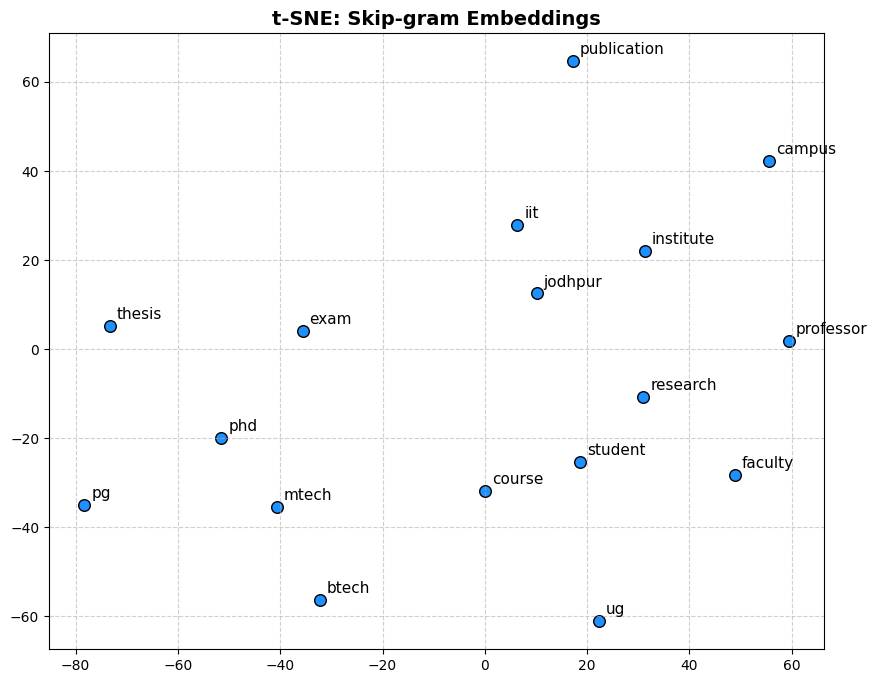

Generating CBOW Plot...


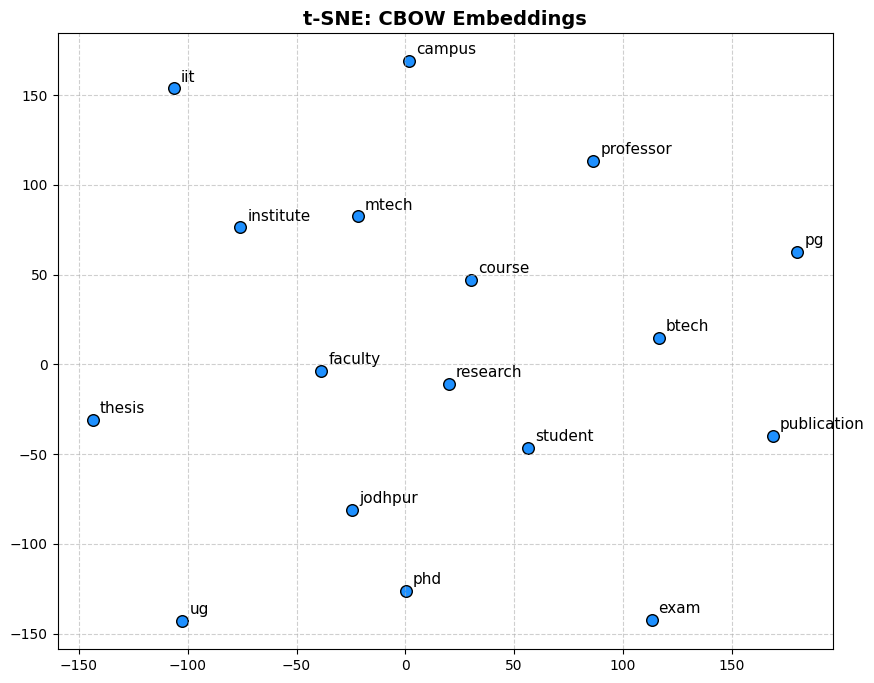

In [ ]:
# Selecting words that form logical clusters in an academic dataset
cluster_terms = [
    "research", "phd", "thesis", "publication", # Cluster 1: Research
    "student", "btech", "mtech", "ug", "pg",    # Cluster 2: Students
    "faculty", "professor", "course", "exam",   # Cluster 3: Academics
    "institute", "campus", "jodhpur", "iit"     # Cluster 4: Entity
]

print("Generating Skip-gram Plot...")
plot_word_vectors(trained_models["Skip-gram_Dim300_Win4_Neg5"], w2i_map, cluster_terms, "t-SNE: Skip-gram Embeddings", red_method='tsne')

print("Generating CBOW Plot...")
plot_word_vectors(trained_models["CBOW_Dim300_Win4_Neg5"], w2i_map, cluster_terms, "t-SNE: CBOW Embeddings", red_method='tsne')

In [ ]:
my_word = "computer"

try:
    # Fetch the embedding tensor using your existing function
    word_tensor = fetch_embedding_vector(trained_models["Skip-gram_Dim300_Win4_Neg5"], my_word, w2i_map, compute_device)
    
    word_vector_list = word_tensor.detach().cpu().numpy().tolist()
    
    # Formatting the numbers and joining them
    formatted_vector_string = ", ".join([f"{val:.4f}" for val in word_vector_list])
    
    print(f"{my_word} - {formatted_vector_string}")

except ValueError as e:
    print(e)

computer - -0.0586, 0.0010, 0.0199, 0.0896, -0.0098, -0.1565, -0.0916, -0.0768, 0.0795, -0.0646, -0.0658, -0.2663, 0.2171, 0.0256, 0.2147, 0.1558, -0.2008, 0.2832, 0.1792, -0.2952, 0.2980, -0.0169, -0.0076, -0.2260, 0.2171, -0.2065, 0.1265, -0.0982, -0.1638, -0.0023, 0.2236, -0.2831, 0.2443, 0.0763, -0.1512, 0.1884, -0.0863, -0.1120, 0.1013, -0.3083, -0.0297, 0.0418, -0.0859, 0.3201, 0.0091, -0.0361, -0.0900, -0.1367, -0.4244, 0.1700, -0.1148, -0.1075, 0.2071, -0.2288, 0.0395, -0.3923, -0.0457, 0.2951, -0.1646, -0.0489, 0.1415, -0.1663, -0.2327, -0.0919, -0.1054, -0.0320, 0.1143, 0.0141, 0.0353, -0.1294, -0.0868, 0.1371, 0.0084, -0.0136, 0.0819, 0.0551, 0.1530, -0.2154, -0.3025, 0.3116, -0.3378, 0.0352, -0.0774, 0.0166, 0.1516, -0.2085, -0.0648, -0.3455, 0.1585, 0.1498, -0.0991, -0.0898, 0.1053, -0.1273, -0.1179, -0.0286, -0.2468, -0.0038, -0.1440, 0.0203, -0.0849, -0.0451, 0.0443, 0.2169, 0.1907, -0.3042, -0.0473, 0.0596, 0.1337, 0.1426, 0.2110, -0.0861, -0.0150, 0.0050, -0.1159, 0.07